# 02 · Comprensión de los datos (CRISP-DM — Fase 2)

Exploramos el **catálogo sísmico regional 1983 – agosto 2026 (M ≥ 4.0)**:
calidad, completitud, distribuciones de magnitud y profundidad, y patrones
espaciales. Al final estimamos el valor *b* de Gutenberg-Richter, un insumo
clásico del peligro sísmico probabilístico.

In [1]:
# --- Configuración común: rutas, imports y estilo ---
import os
import sys
import pathlib

In [2]:
RAIZ = pathlib.Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
FIG = pathlib.Path("reports/figures")
FIG.mkdir(parents=True, exist_ok=True)
print("Entorno listo. Raíz:", RAIZ)

Entorno listo. Raíz: C:\Users\Jordan\.zcode\workspace\default\riesgo-sismico-ecuador


In [5]:
# --- Carga del catálogo crudo (M≥4, 1983–2026) ---
catalogo = pd.read_csv("data/raw/catalogo_sismico_ecuador_1983_2026.csv")
catalogo["fecha_hora"] = pd.to_datetime(catalogo["time"], utc=True)
catalogo = catalogo[catalogo["type"] == "earthquake"]
print(f"Eventos M≥4 en la región de estudio: {len(catalogo)}")
catalogo[["time", "latitude", "longitude", "depth", "mag", "magType", "place"]].head()

Eventos M≥4 en la región de estudio: 2589


,time,latitude,longitude,depth,mag,magType,place
0,1983-02-13T14:01:36.340Z,-4.965,-80.327,33.0,4.4,mb,"4 km SSE of Tambo Grande, Peru"
1,1983-02-18T08:55:46.910Z,-3.113,-79.053,105.1,5.1,mb,"24 km SSW of Cuenca, Ecuador"
2,1983-02-27T01:20:26.360Z,-4.005,-76.404,126.6,4.2,mb,"58 km S of Alianza Cristiana, Peru"
3,1983-03-15T17:15:36.080Z,0.587,-78.209,125.4,4.8,mb,"27 km NNW of Ibarra, Ecuador"
4,1983-03-20T23:45:39.930Z,1.550,-79.626,33.0,4.6,mb,"65 km N of Esmeraldas, Ecuador"


In [6]:
# --- Estadísticas descriptivas básicas ---
catalogo[["mag", "depth", "latitude", "longitude"]].describe().round(2)

,mag,depth,latitude,longitude
count,2589.00,2589.00,2589.00,2589.00
mean,4.62,61.48,-2.08,-78.85
std,0.48,52.91,2.32,1.63
min,4.00,0.00,-6.00,-82.00
25%,4.30,26.08,-3.84,-80.34
50%,4.50,35.30,-2.12,-78.93
75%,4.80,95.55,-0.68,-77.59
max,8.00,250.00,3.00,-74.01


**Lectura inicial:**
- Magnitudes entre 4.0 y 8.0 (el mayor evento del período es el M7.8 de Pedernales, 2016).
- Profundidades desde ~0 km (corticales) hasta >600 km (sismicidad profunda
  de subducción bajo la Amazonía occidental).

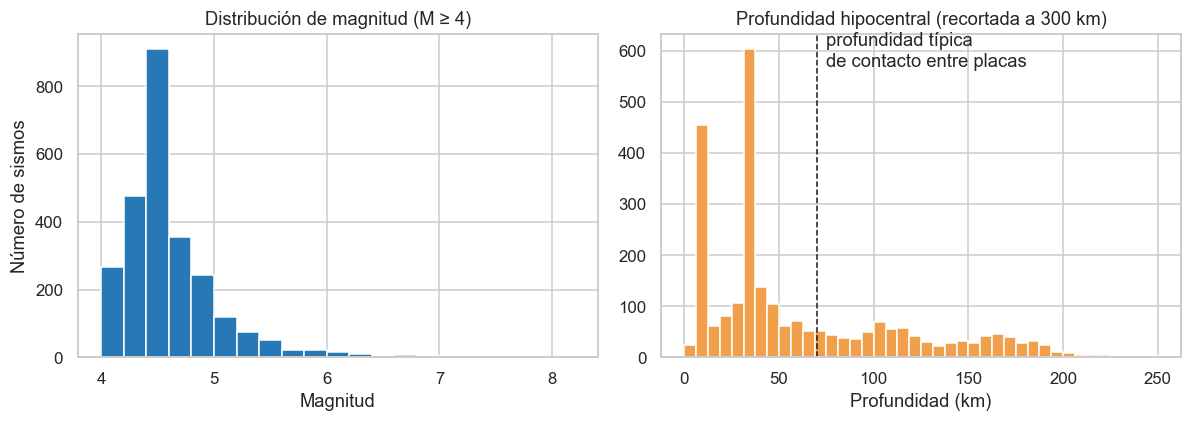

In [7]:
# --- Figura: distribución de magnitudes y profundidades ---
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
ejes[0].hist(catalogo["mag"], bins=np.arange(4, 8.3, 0.2), color="#2878B5", edgecolor="white")
ejes[0].set_title("Distribución de magnitud (M ≥ 4)")
ejes[0].set_xlabel("Magnitud"); ejes[0].set_ylabel("Número de sismos")
ejes[1].hist(catalogo["depth"].clip(upper=300), bins=40, color="#F0A04B", edgecolor="white")
ejes[1].axvline(70, ls="--", c="k", lw=1)
ejes[1].text(75, ejes[1].get_ylim()[1]*0.9, "profundidad típica\nde contacto entre placas")
ejes[1].set_title("Profundidad hipocentral (recortada a 300 km)")
ejes[1].set_xlabel("Profundidad (km)")
plt.tight_layout()
plt.savefig(FIG / "02_distribuciones_mag_prof.png", bbox_inches="tight")
plt.show()

- La distribución de magnitud decae aproximadamente exponencialmente, como
  predice la ley de Gutenberg-Richter (más abajo la cuantificamos).
- El histograma de profundidad muestra **dos poblaciones**: sismos someros
  (<70 km, corticales y de la interfaz de subducción) y un grupo profundo
  (>150 km, intraslab bajo el oriente).

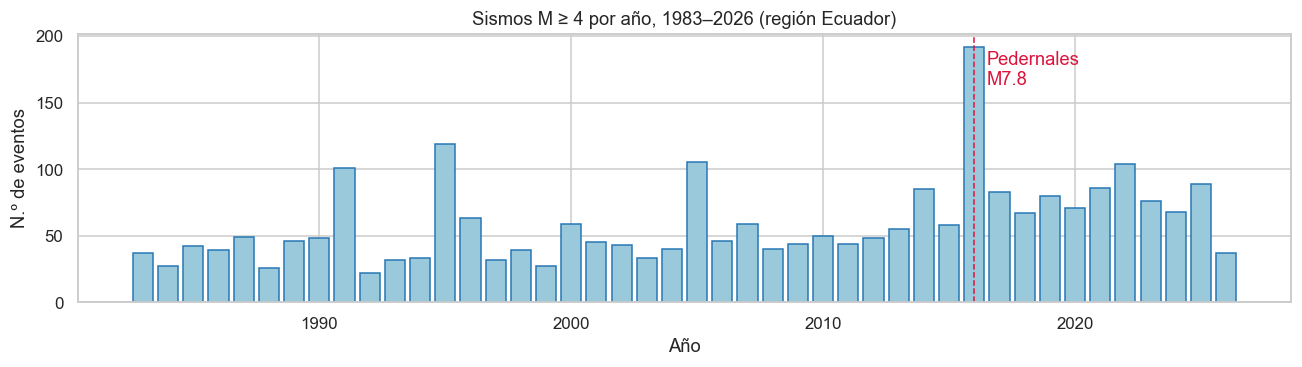

In [8]:
# --- Figura: sismicidad por año (completitud del catálogo) ---
por_anio = catalogo.groupby(catalogo["fecha_hora"].dt.year).size()
fig, eje = plt.subplots(figsize=(12, 3.5))
eje.bar(por_anio.index, por_anio.values, color="#9AC9DB", edgecolor="#2878B5")
eje.set_title("Sismos M ≥ 4 por año, 1983–2026 (región Ecuador)")
eje.set_xlabel("Año"); eje.set_ylabel("N.º de eventos")
eje.axvline(2016, ls="--", c="crimson", lw=1)
eje.text(2016.5, por_anio.max()*0.85, "Pedernales\nM7.8", color="crimson")
plt.tight_layout()
plt.savefig(FIG / "02_sismos_por_anio.png", bbox_inches="tight")
plt.show()

**Completitud:** el número de eventos por año no es constante — aumenta con el
tiempo, reflejo de la mejora de la red sísmica nacional (más estaciones =
detección de magnitudes menores). Los picos corresponden a **secuencias de
réplicas** (visiblemente 2016). Por eso, para estadísticas de tasa usamos
magnitud de completitud Mc = 4.0 y tratamos las réplicas por separado (notebook 05).

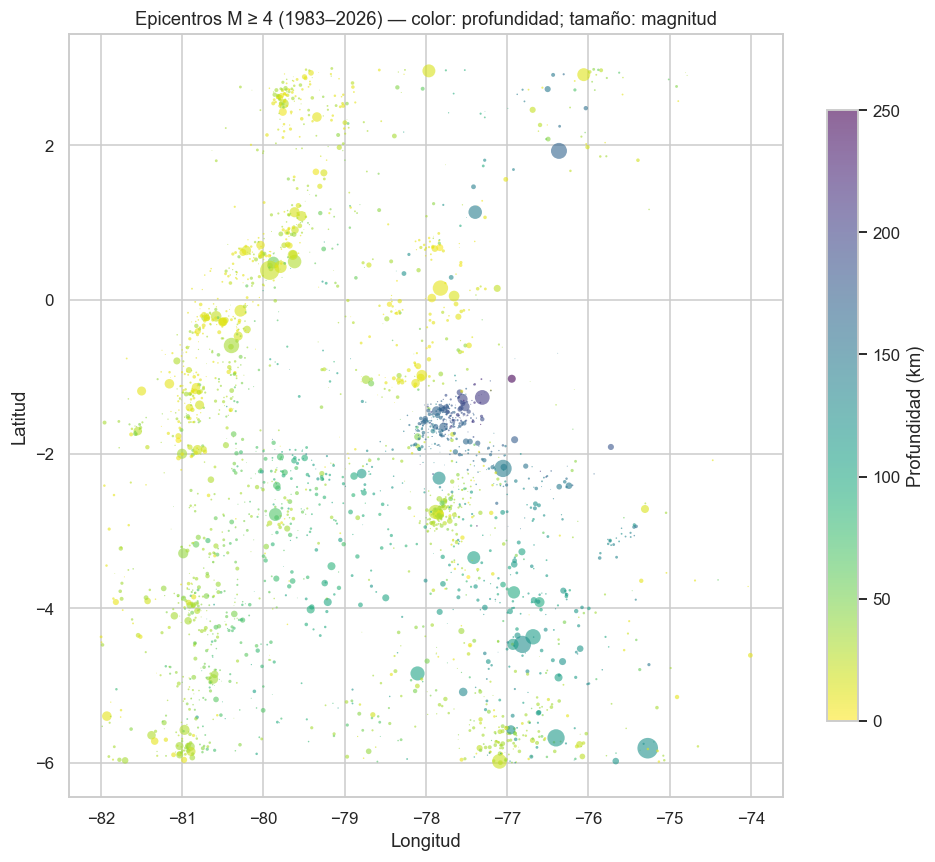

In [9]:
# --- Figura: mapa de epicentros ---
fig, eje = plt.subplots(figsize=(9, 8))
cat = catalogo.copy()
disp = cat[cat["longitude"] > -83]  # excluye islas Galápagos solo para la vista
sc = eje.scatter(disp["longitude"], disp["latitude"], c=disp["depth"], s=(disp["mag"]-3.5)**3*2,
                 cmap="viridis_r", alpha=0.6, edgecolor="none")
eje.set_title("Epicentros M ≥ 4 (1983–2026) — color: profundidad; tamaño: magnitud")
eje.set_xlabel("Longitud"); eje.set_ylabel("Latitud")
plt.colorbar(sc, ax=eje, label="Profundidad (km)", shrink=0.8)
plt.tight_layout()
plt.savefig(FIG / "02_mapa_epicentros.png", bbox_inches="tight")
plt.show()

El patrón espacial es el esperado para un margen convergente:
- Una **banda densa frente a la costa** (interfaz de subducción Nazca–Sudamericana).
- **Sismicidad profunda** (colores cálidos) desplazada hacia el este, bajo la
  Amazonía occidental: el slab de Nazca descendiendo.
- Eventos corticales dispersos en la Sierra, asociados a fallas activas.

In [10]:
# --- Ley de Gutenberg-Richter y valor b (MLE de Aki, 1965) ---
# log10(N(M≥m)) = a − b·m   →   b describe el balance sismo grande/pequeño
mc = 4.0
mags = catalogo.loc[catalogo["mag"] >= mc, "mag"]
b_mle = np.log10(np.e) / (mags.mean() - mc)   # MLE de Aki para magnitudes CONTINUAS
a_mle = np.log10(len(mags)) + b_mle * mc

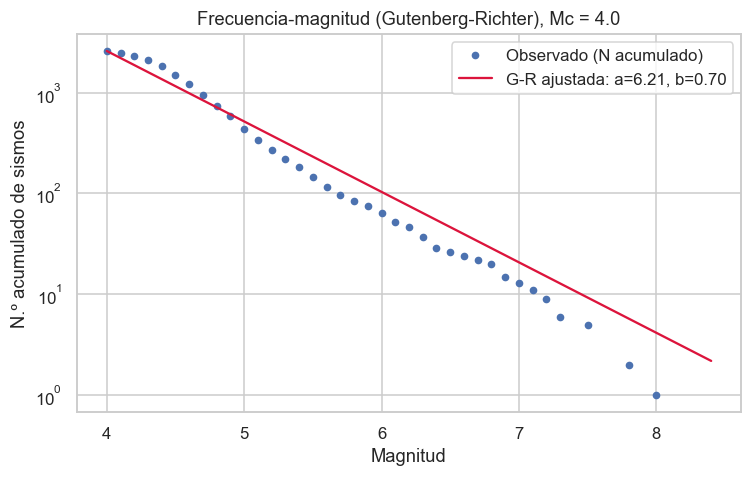

In [11]:
ejem = np.arange(mc, 8.5, 0.1)
acum = np.array([(mags >= m).sum() for m in ejem])
fig, eje = plt.subplots(figsize=(7, 4.5))
eje.semilogy(mags.value_counts().sort_index().index,
             np.cumsum(mags.value_counts().sort_index().values[::-1])[::-1], "o",
             ms=4, label="Observado (N acumulado)")
eje.semilogy(ejem, 10 ** (a_mle - b_mle * ejem), "-", c="crimson",
             label=f"G-R ajustada: a={a_mle:.2f}, b={b_mle:.2f}")
eje.set_title("Frecuencia-magnitud (Gutenberg-Richter), Mc = 4.0")
eje.set_xlabel("Magnitud"); eje.set_ylabel("N.º acumulado de sismos")
eje.legend()
plt.tight_layout()
plt.savefig(FIG / "02_gutenberg_richter.png", bbox_inches="tight")
plt.show()

In [12]:
print(f"Valor b (MLE de Aki) = {b_mle:.2f} | valor a = {a_mle:.2f} | N(M≥4) = {len(mags)}")

Valor b (MLE de Aki) = 0.70 | valor a = 6.21 | N(M≥4) = 2589


**Interpretación del valor b:** valores típicos regionales rondan ~1 (por cada
sismo de magnitud M, ~10 de magnitud M−1). Nuestro b ≈ 0.7 es algo bajo pero
plausible: el catálogo mezcla escalas (mb —que satura cerca de M6—, mww, mw),
lo que aplana la cola superior de la distribución. Verificación simple por
ratios: N(M≥4)/N(M≥5) ≈ 6 y N(M≥5)/N(M≥6) ≈ 7 → b ≈ 0.8, consistente.
Este parámetro alimenta los modelos clásicos de peligro sísmico probabilístico
(aunque nuestro índice del notebook 04 usa un enfoque más simple y transparente).

## Resumen de la fase 2
| Aspecto | Hallazgo |
|---|---|
| Volumen | ~2.600 eventos M≥4 en 43 años |
| Completitud | Mc = 4.0 razonable para todo el período; M≥3.5 fiable solo tras ~2011 |
| Magnitud máx. | 8.0 (offshore); 7.8 en el continente (Pedernales 2016) |
| Sismicidad | Bandas de subducción frente a costa + profunda bajo Amazonía |
| G-R | b ≈ 0.7–0.8 (MLE continuo y ratios), margen de subducción activo |